In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pysimdamicm
import pandas as pd
import awkward as ak

In [5]:
file = "/home/dsalma/damicm-ml/simulation/test_1/out_simulCCDimg_logb9c4085_CCDSensor_PV_55a26z1_2000_s0.root"

In [6]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'pixelizedEvent;1', 'geant4_config;1', 'process_config;1']


In [7]:
clustersRec_tree = f["clustersRec"]

In [8]:
df = clustersRec_tree.arrays(library="pd")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 71 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event              186 non-null    int32  
 1   Nclusters          186 non-null    int32  
 2   DX                 186 non-null    awkward
 3   DY                 186 non-null    awkward
 4   DZ                 186 non-null    awkward
 5   Energy             186 non-null    awkward
 6   Npix               186 non-null    awkward
 7   PosX               186 non-null    awkward
 8   PosY               186 non-null    awkward
 9   PosZ               186 non-null    awkward
 10  Qmax               186 non-null    awkward
 11  QmaxX              186 non-null    awkward
 12  QmaxY              186 non-null    awkward
 13  QmaxZ              186 non-null    awkward
 14  RMSX               186 non-null    awkward
 15  RMSY               186 non-null    awkward
 16  RMSZ               186 non

In [10]:
print(df["pixels_x"][0])

[[308, 308, 309]]


In [11]:
print(df["Energy"])

0                       [0.047024231404066086]
1                          [6.475704669952393]
2                         [6.5663604736328125]
3                         [0.7646167874336243]
4                          [6.479925155639648]
                        ...                   
181                        [6.461753845214844]
182    [5.316186428070068, 1.1424671411514282]
183                       [6.3767266273498535]
184                        [6.463881492614746]
185                        [6.548206329345703]
Name: Energy, Length: 186, dtype: awkward


In [12]:
relevant_df = df[["pixels_x", "pixels_y", "pixels_E"]]

In [13]:
relevant_df.head()

,pixels_x,pixels_y,pixels_E
0,"[list([308, 308, 309])]","[list([165, 167, 165])]","[list([0.007743132300674915, 0.010821591131389..."
1,"[list([243, 244, 244, 244, 245, 245, 245, 246,...","[list([225, 224, 225, 226, 224, 225, 226, 225,...","[list([0.038250360637903214, 0.145776271820068..."
2,"[list([1281, 1281, 1282, 1282, 1282, 1282, 128...","[list([120, 121, 119, 120, 121, 122, 119, 120,...","[list([0.011111369356513023, 0.010032718069851..."
3,[list([1238])],[list([323])],[list([0.7646167874336243])]
4,"[list([1403, 1403, 1404, 1404])]","[list([351, 352, 351, 352])]","[list([1.41781485080719, 2.5177693367004395, 0..."


In [14]:
for c in relevant_df.columns:
    relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))

relevant_df["event"] = range(len(relevant_df))
relevant_df = relevant_df.explode(["pixels_x", "pixels_y", "pixels_E"]).reset_index(drop=True)

/tmp/ipykernel_10862/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_10862/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_10862/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

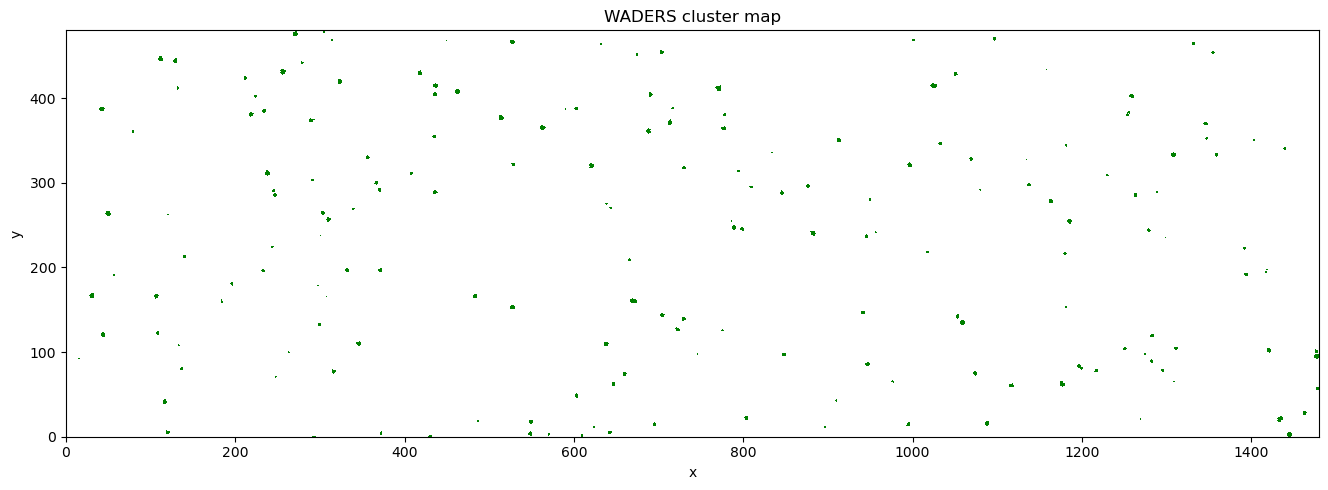

In [17]:
img = np.zeros((1500, 6000), dtype=int)

xs = relevant_df["pixels_x"].astype(int).values - 1
ys = relevant_df["pixels_y"].astype(int).values - 1
img[ys, xs] = 1

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(18, 5))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1480)
plt.ylim(0, 480)
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()

# finally this looks good!

In [18]:
relevant_df.head()

,pixels_x,pixels_y,pixels_E,event
0,308,165,0.007743,0
1,308,167,0.010822,0
2,309,165,0.02846,0
3,243,225,0.03825,1
4,244,224,0.145776,1


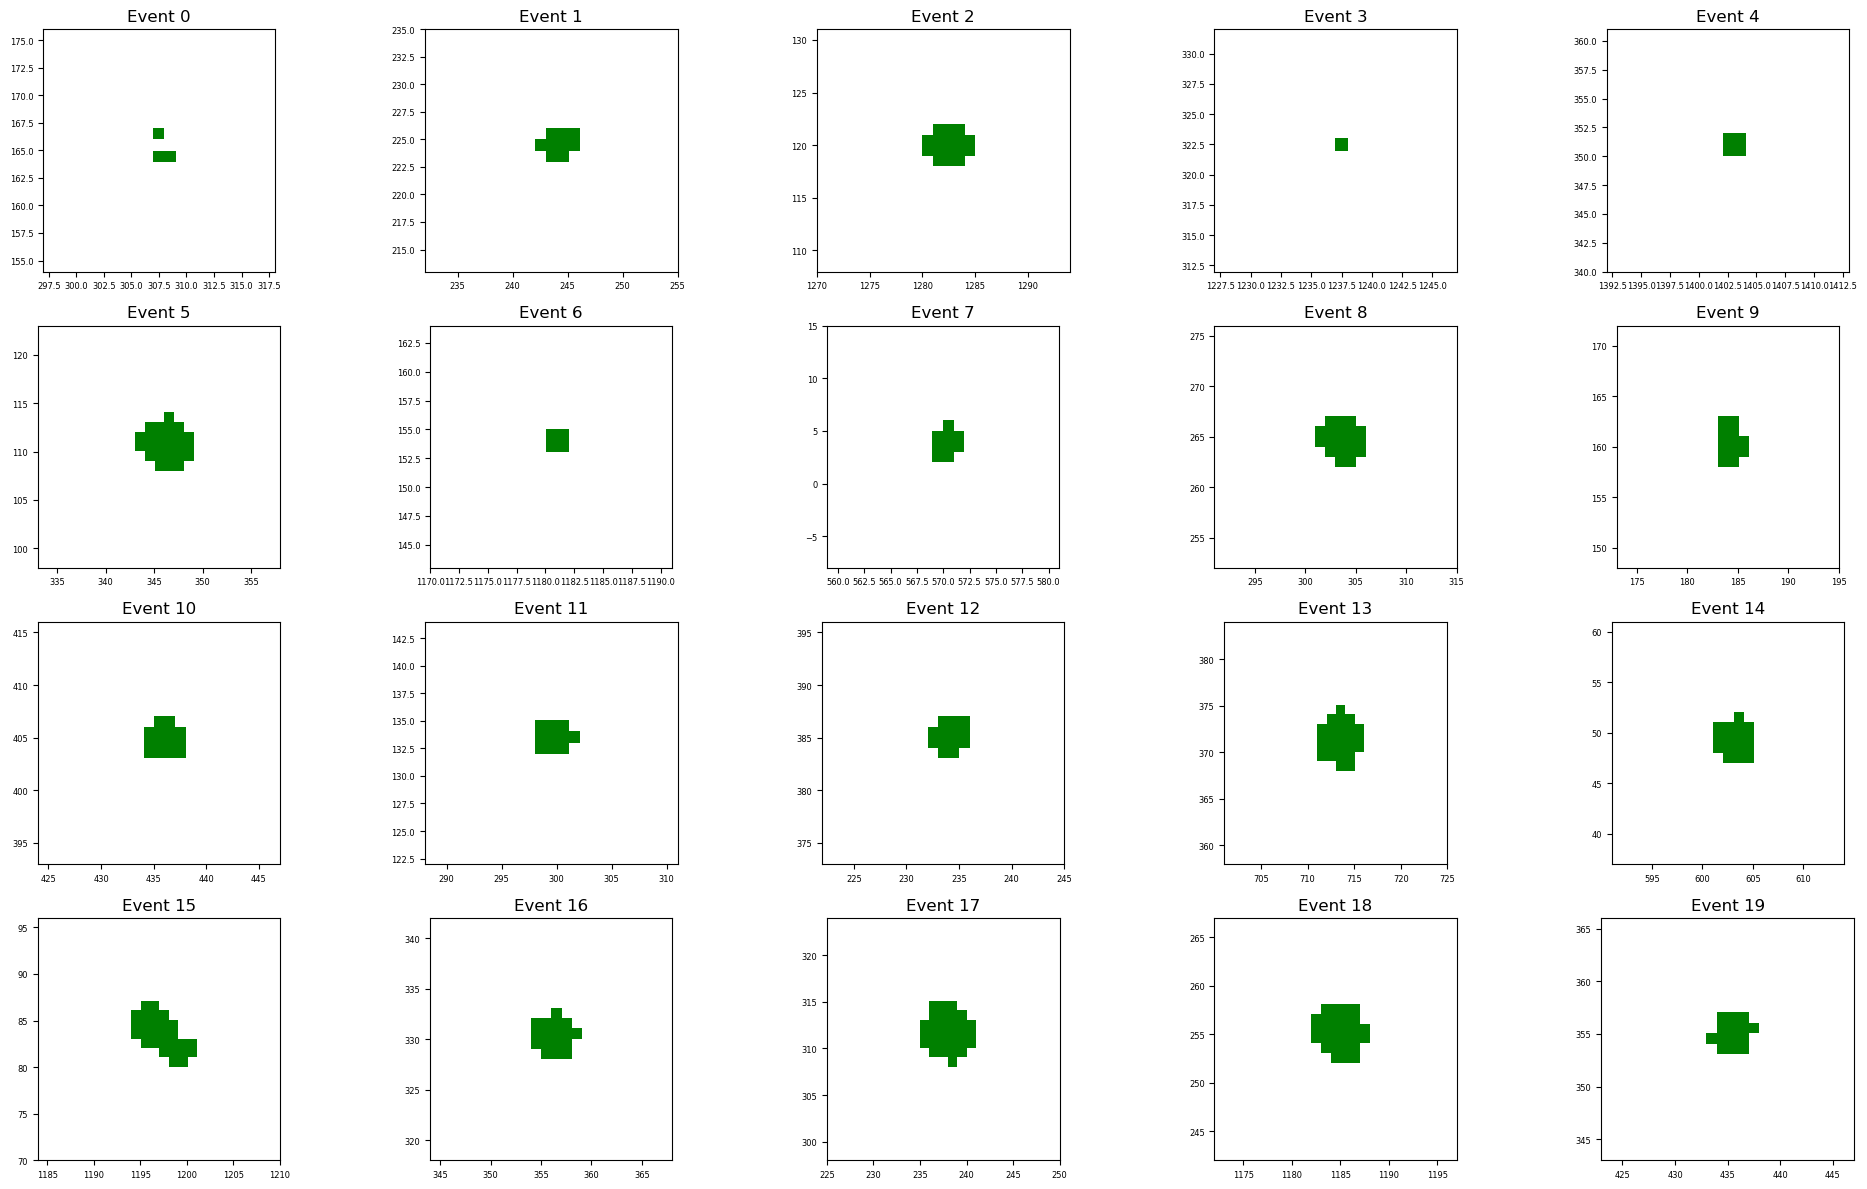

In [19]:
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

for i, (event_id, group) in enumerate(relevant_df.groupby("event")):
    if i >= 20:
        break
    
    xs = group["pixels_x"].astype(int).values - 1
    ys = group["pixels_y"].astype(int).values - 1
    
    pad = 10
    x0, x1 = xs.min() - pad, xs.max() + pad
    y0, y1 = ys.min() - pad, ys.max() + pad
    
    img = np.zeros((y1 - y0, x1 - x0), dtype=int)
    img[ys - y0, xs - x0] = 1
    
    axes[i].imshow(img, origin="lower", cmap=cmap, interpolation="nearest",
                   extent=[x0, x1, y0, y1])  # set real coordinates
    axes[i].set_title(f"Event {event_id}")
    axes[i].tick_params(labelsize=6)

plt.tight_layout()
plt.show()

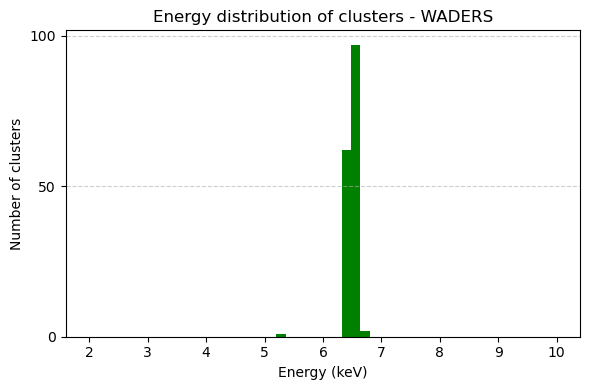

In [20]:
energies = df["Energy"].apply(lambda x: ak.to_list(x[0]))

plt.figure(figsize=(6, 4))
plt.hist(energies, bins=50, color="green", range=(2, 10))
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters - WADERS")

ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 50))
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Okay now see if we can reconstruct the original image

In [21]:
pixelizedEvent = f["pixelizedEvent"]

In [22]:
df2 = pixelizedEvent.arrays(library="pd")

In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   event                     186 non-null    int32  
 1   Npix                      186 non-null    int32  
 2   ccd                       186 non-null    int32  
 3   pixels_Edep               186 non-null    awkward
 4   pixels_N_carried_charges  186 non-null    awkward
 5   pixels_alpha              186 non-null    awkward
 6   pixels_electron           186 non-null    awkward
 7   pixels_gamma              186 non-null    awkward
 8   pixels_ion                186 non-null    awkward
 9   pixels_neutron            186 non-null    awkward
 10  pixels_pdg                186 non-null    awkward
 11  pixels_sigma_xy           186 non-null    awkward
 12  pixels_silicon            186 non-null    awkward
 13  pixels_time               186 non-null    awkward
 14  pixels_x  

In [24]:
relevant_df2 = df2[["pixels_x", "pixels_y", "pixels_Edep"]]

In [25]:
relevant_df2.head()

,pixels_x,pixels_y,pixels_Edep
0,"[list([164, 165, 166, 164, 165, 166, 167, 164,...","[list([307, 307, 307, 308, 308, 308, 308, 309,...","[list([0.0037400000728666782, 0.00374000007286..."
1,"[list([224, 225, 224, 225, 226, 224, 225, 226,...","[list([243, 243, 244, 244, 244, 245, 245, 245,...","[list([0.0037400000728666782, 0.03739999979734..."
2,"[list([120, 121, 119, 120, 121, 122, 119, 120,...","[list([1281, 1281, 1282, 1282, 1282, 1282, 128...","[list([0.011219999752938747, 0.011219999752938..."
3,[list([323])],[list([1238])],[list([0.766700029373169])]
4,"[list([351, 352, 351, 352])]","[list([1403, 1403, 1404, 1404])]","[list([1.4174599647521973, 2.5170199871063232,..."


In [26]:
for c in relevant_df2.columns:
    relevant_df2[c] = relevant_df2[c].apply(lambda x: ak.to_list(x[0]))

relevant_df2["event"] = range(len(relevant_df2))
relevant_df2 = relevant_df2.explode(["pixels_x", "pixels_y", "pixels_Edep"]).reset_index(drop=True)

/tmp/ipykernel_10862/448259659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df2[c] = relevant_df2[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_10862/448259659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df2[c] = relevant_df2[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_10862/448259659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [27]:
relevant_df2.head()

,pixels_x,pixels_y,pixels_Edep,event
0,164,307,0.00374,0
1,165,307,0.00374,0
2,166,307,0.00374,0
3,164,308,0.00748,0
4,165,308,0.00748,0


In [22]:
d = np.load("/home/dsalma/damicm-ml/simulation/test_1/out_simulCCDimg_logb9c4085_CCDSensor_PV_55a26z1_2000_s0_data.npz")

In [23]:
d["image"].shape

(6000, 1500)

In [24]:
ccd_img = d["image"][:1480, :480]

In [25]:
mask = d["mask"][:1480, :480]

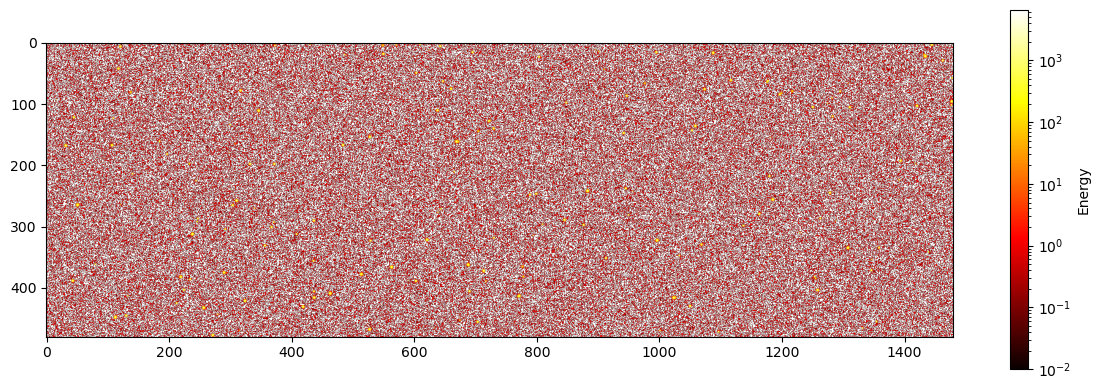

In [26]:
import matplotlib.colors as colors

plt.figure(figsize=(12, 4))
plt.imshow(ccd_img.T, cmap='hot', norm=colors.LogNorm(vmin=1e-2, vmax=ccd_img.max()))
plt.colorbar(label='Energy')
plt.tight_layout()
plt.show()

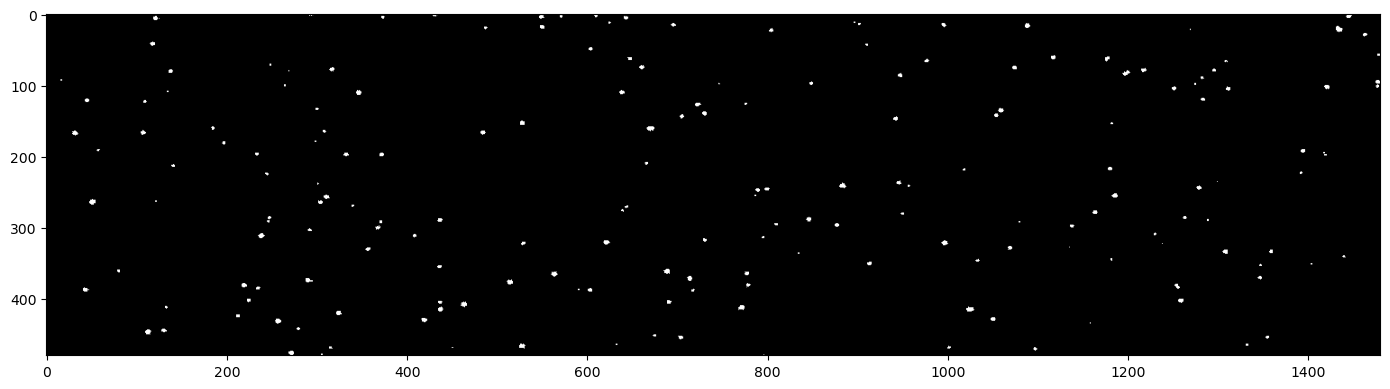

In [28]:
plt.figure(figsize=(14, 4))
plt.imshow(mask.T, cmap='gray', aspect='auto')  # ~ flips so False=white, True=black
plt.tight_layout()
plt.show()